<a href="https://www.kaggle.com/code/riteshkumarweb/voting-regression-ensemble-learning?scriptVersionId=318741986" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv
/kaggle/input/datasets/riteshkumarweb/housing-dataset/1553768847-housing.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv')

In [3]:
df2 = pd.read_csv('/kaggle/input/datasets/riteshkumarweb/housing-dataset/1553768847-housing.csv')

In [4]:
df2

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [5]:
df2.drop(columns=['longitude','ocean_proximity','total_bedrooms'],inplace=True)


In [6]:
df2.sample(10)

,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
4714,34.06,52,843,333,151,4.5192,446000
4391,34.07,27,1190,1795,422,1.7016,160000
17876,37.39,25,3495,2484,797,4.8145,230700
14847,32.68,26,3071,2156,568,2.9318,112400
15464,33.16,2,4624,2091,808,3.6736,214500
3288,39.04,23,1618,425,244,1.9833,111500
12450,33.69,17,720,333,117,1.6509,85700
16794,37.66,36,5456,2761,916,4.7755,280700
19563,37.59,29,1727,1063,386,1.8929,63600
1094,39.79,16,1453,904,286,3.5735,89600


In [7]:
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [8]:
#df.isnull().sum()
df2.isnull().sum()

latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [9]:
X1 = df2.iloc[:,0:7]
X1

,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,37.88,41,880,322,126,8.3252,452600
1,37.86,21,7099,2401,1138,8.3014,358500
2,37.85,52,1467,496,177,7.2574,352100
3,37.85,52,1274,558,219,5.6431,341300
4,37.85,52,1627,565,259,3.8462,342200
...,...,...,...,...,...,...,...
20635,39.48,25,1665,845,330,1.5603,78100
20636,39.49,18,697,356,114,2.5568,77100
20637,39.43,17,2254,1007,433,1.7000,92300
20638,39.43,18,1860,741,349,1.8672,84700


In [10]:
y1 =df2.iloc[:,-1]
y1

0        452600
1        358500
2        352100
3        341300
4        342200
          ...  
20635     78100
20636     77100
20637     92300
20638     84700
20639     89400
Name: median_house_value, Length: 20640, dtype: int64

In [11]:
X = df.iloc[:,[0]]
X 

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [12]:
y = df.iloc[:,-1]
y

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

In [13]:
print(X.shape)
print(X1.shape)

(49, 1)
(20640, 7)


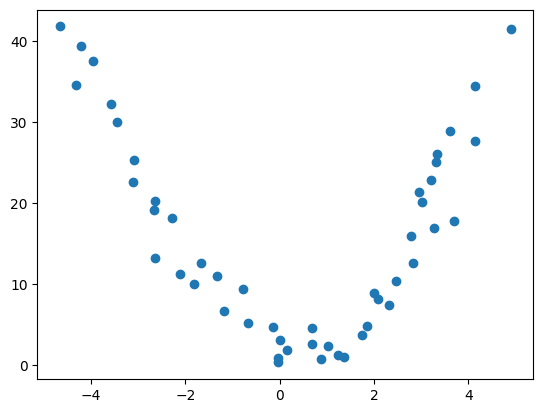

In [14]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

#poly = PolynomialFeatures()
#X_poly = poly.fit_transform(X)
from sklearn.linear_model import Ridge, Lasso
#lr = Ridge(alpha=1.0) 

lr = LinearRegression()
dt = DecisionTreeRegressor(splitter='random',max_depth=5)
svr = SVR()

estimators = [('lr',lr), ('dt',dt), ('svr',svr)]

for estimator in estimators:
    score = cross_val_score(estimator[1],X1,y1,cv=10,scoring='r2')
    print(estimator[0],np.round(np.mean(score),2))

lr 1.0
dt 0.95
svr -0.21


# Using Voting Regressor wiht Cross Validation cross_val_score

In [16]:
estimators = [('lr',lr), ('dt',dt), ('svr',svr)]

from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import cross_val_score

vc = VotingRegressor(estimators=estimators,weights=None)
for estimator in estimators:
    score = cross_val_score(vc, X1,y1 , cv =10 ,scoring='r2')
    print(estimator[0],np.round(np.mean(score),2))

lr 0.85
dt 0.85
svr 0.84


# Using Tradition Method r2_score and using Voting Regression on Train set only 

In [17]:
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Split data first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train voting classifier
vc = VotingRegressor(estimators=estimators)
vc.fit(X_train, y_train)

# Make predictions
y_pred = vc.predict(X_test)

# Calculate R2 score
r2score = r2_score(y_test, y_pred)
print(f"R2 Score: {r2score}")

R2 Score: 0.6585023093272209


In [18]:
cross_score = cross_val_score(vc,X_train,y_train,cv=10,scoring='r2') #Model is too simple on train data it remember all things
#and give the accuracy is 100% but failed on the test set given below when we do cross_val_score 
print(f'The cross validation score is {np.round(np.mean(cross_score))}')

The cross validation score is 0.0


In [19]:
cross_score = cross_val_score(vc,X,y,cv=10,scoring='r2')
print(f'The cross validation score is {np.round(np.mean(cross_score))}')

The cross validation score is -14.0


# 😂 My score is in the - negetive 